# Hitting a Phase-Space Point — the Dirichlet targeting map

### How the knobs $(\delta,\varphi_\mathrm{train},N)$ place a probe point β

*Strobo-Travels-Deep · `wp-wigner-tomography` · explanatory notebook · 2026-05-17*

The [χ→Wigner notebook](./wpw_chi_to_wigner.ipynb) assumed we can
sample the characteristic function χ on a grid of probe points β.
This notebook explains the missing mechanical step: **how the
experiment actually places one β**, and how to run that map
*backwards* — choose the physical knobs that land χ exactly on a
Cartesian grid (so the FFT of the previous notebook can be applied).

**Where this sits in WP-W.** This is the WP-W §2 forward map and its
inversion — the engine machinery underneath P1 and D4, and the part
deliverable D3 deliberately *skips* (D3 evaluates analytic χ on the
grid directly; the targeting is only needed when you drive the real
train). It is the WP-W §2 / `analytic_chain.md` §3 content, made
visual. Teaching artefact; the sources below are authoritative.

| Authoritative source | Where |
|---|---|
| Convention-locked derivation | [`notes/analytic_chain.md`](../wp-wigner-tomography/notes/analytic_chain.md) §3 |
| Work program | [`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md) §2 |
| P1 engine-bridge logbook | [`logbook/2026-05-15-ideal-sdf-primitive.md`](../wp-wigner-tomography/logbook/2026-05-15-ideal-sdf-primitive.md) |
| Committed P1 data | `wp-wigner-tomography/numerics/p1_preflight.h5` |

## §1 Plain-language definitions

Read once; the rest of the notebook uses these words in this sense.

- **Per-pulse kick β₀.** One SDF pulse displaces the motion by a
  small fixed amount β₀ (here the v0.2 value 0.05). The analysis
  train fires **N** of them.

- **Per-gap phase x.** Between two pulses the rotating-frame force
  axis advances by a phase $x$ set by how far the drive is detuned:
  $x=(\delta-k\omega_m)\,T_m$ ($T_m$ = one motional period). On
  resonance $x=0$; off resonance the successive kicks point in
  slightly rotated directions.

- **Dirichlet kernel.** Add up the N kicks. When they are aligned
  ($x=0$) they sum **constructively** to the full reach $N\beta_0$.
  As $x$ grows they fan out and partly cancel. The exact sum is the
  *Dirichlet kernel* $\mathcal D_N(x)$ — the same comb-of-pulses
  interference that sharpens as you add more pulses.

- **Reach.** The largest displacement the train can deliver is
  $|\beta_\mathrm{tot}|_\mathrm{max}=N\beta_0$ (all kicks aligned).
  This sets the phase-space window the protocol can probe.

- **Central (monotone) branch.** As $x$ goes $0\!\to\!2\pi/N$,
  $|\mathcal D_N|$ falls smoothly from $N$ to $0$ — a one-to-one
  stretch. Targeting always uses this branch so the inversion has a
  unique answer.

- **Carrier tooth k.** The drive can sit on the carrier ($k=0$) or a
  motional sideband ($k=\pm1,\dots$); only the detuning *relative to
  the chosen tooth*, $\delta-k\omega_m$, matters. WP-W uses the
  carrier, $k=0$.

- **Inverse-Dirichlet targeting.** The forward map gives β from the
  knobs. Reconstruction needs the opposite: *given* a wanted
  Cartesian point β★, solve for the knobs $(\delta,\varphi_\mathrm{train})$
  that deliver it. A wanted point outside the reach disk is
  **unreachable** and gets zero-filled before the FFT.

## §2 The forward map, precisely

Pulse $n\in[0,N)$ delivers the kick $\beta_0\,e^{i(\varphi_\mathrm{train}+n x)}$
(train phase plus $n$ steps of the per-gap phase $x$). The total is a
**geometric sum**:

$$\beta_\mathrm{tot}(\delta,\varphi_\mathrm{train};N)
=\beta_0\,e^{i\varphi_\mathrm{train}}\sum_{n=0}^{N-1}e^{inx}
=\beta_0\,e^{i\varphi_\mathrm{train}}\,\mathcal D_N(x),
\qquad
\mathcal D_N(x)=e^{i(N-1)x/2}\,\frac{\sin(Nx/2)}{\sin(x/2)}.$$

Key facts: $\mathcal D_N(0)=N$ (peak reach $N\beta_0$). The
**targeting (monotone) branch** is the *one-sided* peak→first-zero
stretch $0\le x\le 2\pi/N$, i.e. $0\le(\delta-k\omega_m)/\omega_m\le 1/N$
(a span of $\omega_m/N$). The **full central lobe** (first zero
either side of the peak) is twice that,
$|\delta-k\omega_m|/\omega_m\le 1/N$ → total width $2\omega_m/N$.
Either way the **tooth narrows like $1/N$**.

**Inverse-Dirichlet targeting** (the 3 steps, $\arg\beta_0=0$):

1. For target $\beta_\star=r\,e^{i\theta}$ with $r\le N\beta_0$:
   solve $|\mathcal D_N(x)|=r/\beta_0$ for $x$ on the monotone
   branch $0\le x\le 2\pi/N$ (a 1-D root find).
2. $\varphi_\mathrm{train}=\theta-\arg\mathcal D_N(x)=\theta-(N-1)x/2$.
3. Physical detuning offset $\delta-k\omega_m=x/T_m$.

Reusing the **committed** `_common.dirichlet_magnitude` (step-1 left
side) and `_common.inverse_dirichlet` (the committed root-finder) —
no formula is re-implemented here.

## §3 Setup

In [1]:
import os, sys, json, subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt

REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO, "scripts"))
sys.path.insert(0, os.path.join(REPO, "wp-wigner-tomography", "numerics"))

from stroboscopic import HilbertSpace, states
from stroboscopic.ideal_sdf import build_ideal_sdf_train
# Committed, smoke-tested helpers — reused verbatim.
from _common import dirichlet_magnitude, inverse_dirichlet, chi_vacuum

plt.rcParams.update({"figure.dpi": 110})
NUM = os.path.join(REPO, "wp-wigner-tomography", "numerics")
OMEGA_M, BETA0, K = 1.3, 0.05, 0          # carrier tooth k=0; v0.2 beta0
print("setup OK; P1 artefact",
      "present" if os.path.exists(os.path.join(NUM, "p1_preflight.h5"))
      else "MISSING")

setup OK; P1 artefact present


## §4 The Dirichlet kernel — N kicks interfering

We plot $|\mathcal D_N(x)|/N$ from the committed
`_common.dirichlet_magnitude`, for $N=20$ and $N=80$.

**What to look for:** a tall central lobe peaking at $|\mathcal D_N|=N$
(value 1 after the $/N$ scaling) at $x=0$; smaller side lobes; and
the central lobe **narrowing like $1/N$** — the $N=80$ tooth is 4×
sharper than $N=20$. The shaded band is the *monotone branch*
$0\le x\le 2\pi/N$ that targeting uses (only its right half is
single-valued; we invert on it).

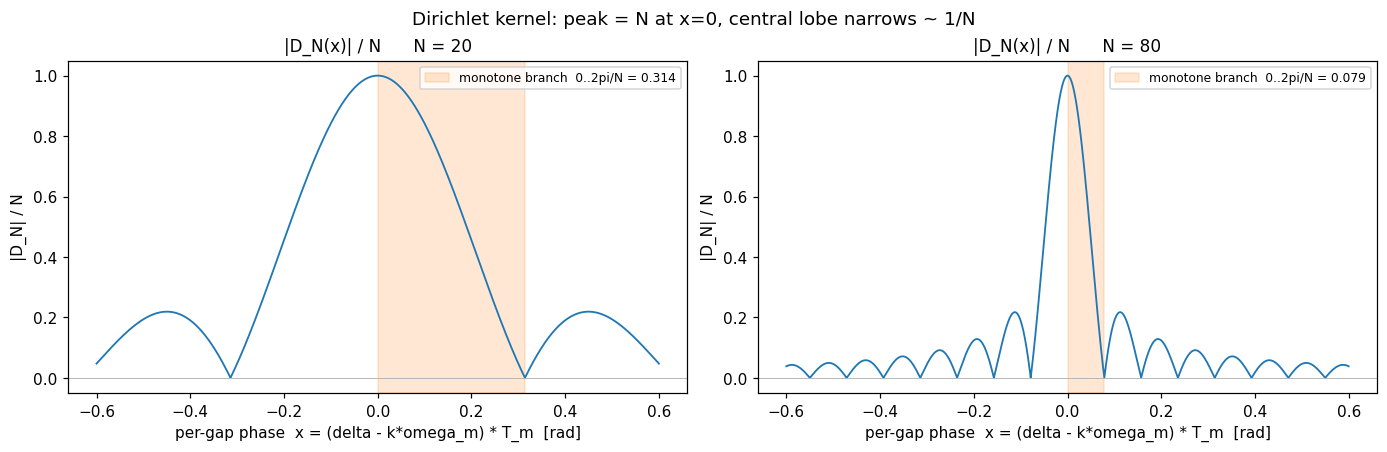

peak check: |D_20(0)|=20.0  |D_80(0)|=80.0  (= N, full reach N*beta0)
targeting branch (one-sided, peak -> first zero):  0 <= (delta - k*omega_m)/omega_m <= 1/N
  1/N = 0.0500 (N=20),  0.01250 (N=80)
  at omega_m/2pi = 1.3 MHz, N=80:  one-sided span = omega_m/N = 16.25 kHz;  full zero-to-zero central lobe = 2*omega_m/N = 32.50 kHz


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0), constrained_layout=True)
xx = np.linspace(-0.6, 0.6, 4001)
for a, N in zip(ax, (20, 80)):
    dm = np.array([dirichlet_magnitude(N, x) for x in xx]) / N
    a.plot(xx, dm, lw=1.2)
    br = 2 * np.pi / N
    a.axvspan(0.0, br, color="tab:orange", alpha=0.18,
              label=f"monotone branch  0..2pi/N = {br:.3f}")
    a.axhline(0, color="0.7", lw=0.6)
    a.set_title(f"|D_N(x)| / N      N = {N}", fontsize=11)
    a.set_xlabel("per-gap phase  x = (delta - k*omega_m) * T_m  [rad]")
    a.set_ylabel("|D_N| / N")
    a.set_ylim(-0.05, 1.05)
    a.legend(loc="upper right", fontsize=8)
fig.suptitle("Dirichlet kernel: peak = N at x=0, central lobe narrows ~ 1/N")
plt.show()
print(f"peak check: |D_20(0)|={dirichlet_magnitude(20,0.0):.1f}  "
      f"|D_80(0)|={dirichlet_magnitude(80,0.0):.1f}  (= N, full reach N*beta0)")
print("targeting branch (one-sided, peak -> first zero):  "
      "0 <= (delta - k*omega_m)/omega_m <= 1/N")
print(f"  1/N = {1/20:.4f} (N=20),  {1/80:.5f} (N=80)")
print(f"  at omega_m/2pi = 1.3 MHz, N=80:  one-sided span = omega_m/N "
      f"= {1300/80:.2f} kHz;  full zero-to-zero central lobe = 2*omega_m/N "
      f"= {2*1300/80:.2f} kHz")

**Takeaway.** More pulses → a sharper tooth (resolution improves
like $1/N$) but the *usable detuning window shrinks like $1/N$* too.
At $N=80$, $\omega_m/2\pi=1.3$ MHz, the one-sided targeting branch
(peak→first zero) spans only $\omega_m/N=16.25$ kHz; the full
zero-to-zero central lobe is $2\omega_m/N=32.5$ kHz. That trade-off
— sharper targeting vs a tighter detuning-stability requirement — is
a real experimental constraint set entirely by this kernel.

## §5 Inverse-Dirichlet Cartesian targeting

Now the inversion that connects to the FFT notebook. Take the WP-W
v0.2 Cartesian β grid ($N_g=81$, $B=4$, $\Delta\beta=0.10$, with
$N=80$, $\beta_0=0.05$ so reach $=N\beta_0=4.0$). For every node
$\beta_\star$ inside the reach disk we run the 3-step inversion
(committed `inverse_dirichlet` for step 1), then **rebuild** the
displacement by explicitly stacking the $N$ kicks
$\sum_n\beta_0 e^{i(\varphi_\mathrm{train}+nx)}$ — the literal
forward map — and check it lands on the target.

**What to look for:** (left) achieved points sit *exactly* on the
target grid inside the reach circle; corner nodes with
$|\beta_\star|>N\beta_0$ are **unreachable** (red) and will be
zero-filled before the FFT — exactly the zero-fill the χ→Wigner
notebook mentioned. (right) the detuning each node needs: all within
the tiny $|\delta-k\omega_m|/\omega_m\le 1/N$ central band.

reachable nodes: 5025 / 6561   (reach |beta| <= N*beta0 = 4.00)
max |achieved - target| over reachable nodes = 1.51e-11  (exact)
cross-check |sum kicks|/beta0 = 50.000000  vs  dirichlet_magnitude(N,x) = 50.000000


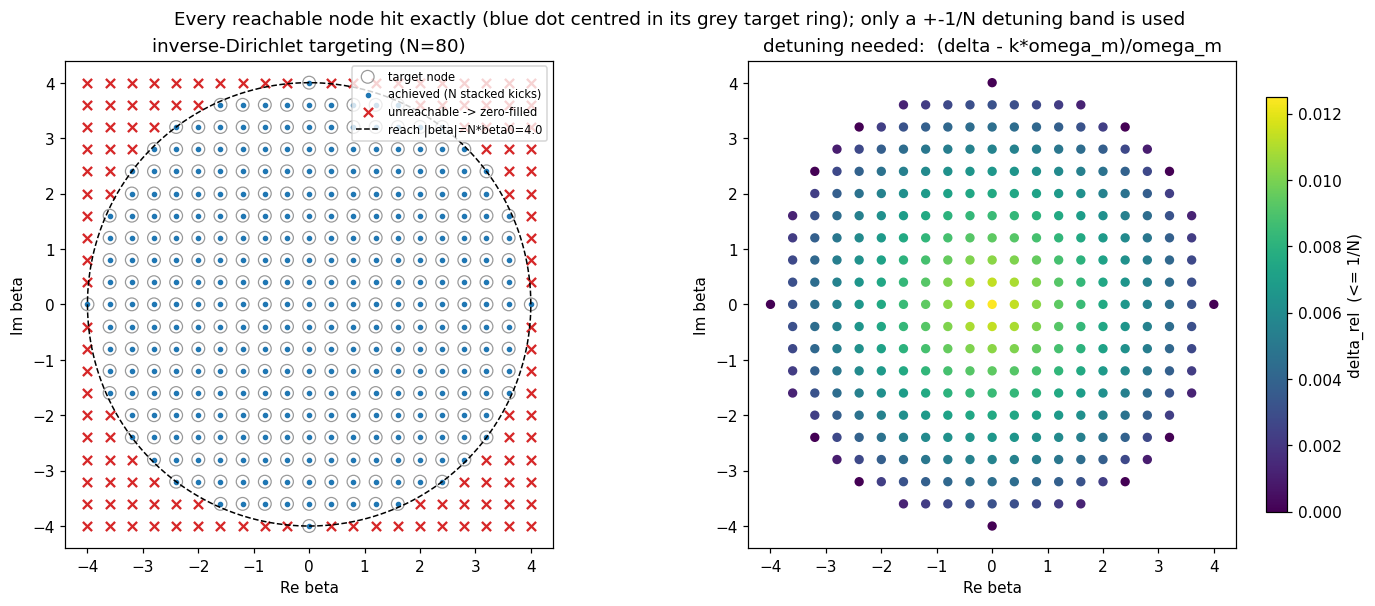

In [3]:
N, B, DBETA = 80, 4.0, 0.10
reach = N * BETA0                                  # = 4.0
g = (np.arange(81) - 40) * DBETA                   # 81-pt Cartesian axis
GX, GY = np.meshgrid(g, g)
beta_star = (GX + 1j * GY).ravel()

T_m = 2.0 * np.pi / OMEGA_M
ach, det_rel, reachable = [], [], []
for bs in beta_star:
    r, th = abs(bs), np.angle(bs)
    if r > reach + 1e-12:
        reachable.append(False); ach.append(np.nan + 0j); det_rel.append(np.nan)
        continue
    x = inverse_dirichlet(N, r / BETA0)            # committed root-finder
    phi = (th - (N - 1) * x / 2.0) % (2.0 * np.pi)
    # explicit forward map: stack the N kicks (the definition itself)
    b_tot = BETA0 * np.sum(np.exp(1j * (phi + np.arange(N) * x)))
    ach.append(b_tot); det_rel.append(x / T_m / OMEGA_M)
    reachable.append(True)
ach = np.array(ach); reachable = np.array(reachable); det_rel = np.array(det_rel)

err = np.nanmax(np.abs(ach[reachable] - beta_star[reachable]))
# cross-check the explicit sum against the committed magnitude helper
xs = inverse_dirichlet(N, 2.5 / BETA0)
print(f"reachable nodes: {reachable.sum()} / {beta_star.size}   "
      f"(reach |beta| <= N*beta0 = {reach:.2f})")
print(f"max |achieved - target| over reachable nodes = {err:.2e}  (exact)")
print(f"cross-check |sum kicks|/beta0 = "
      f"{abs(np.sum(np.exp(1j*np.arange(N)*xs))):.6f}  vs  "
      f"dirichlet_magnitude(N,x) = {dirichlet_magnitude(N, xs):.6f}")

# Plot a decimated sub-lattice so individual target rings vs achieved
# dots are legible (the full-grid count/accuracy above used all 6561).
II, JJ = np.meshgrid(np.arange(81), np.arange(81))
sub = ((II.ravel() % 4 == 0) & (JJ.ravel() % 4 == 0))
sR, sU = sub & reachable, sub & ~reachable
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12.5, 5.4), constrained_layout=True)
a0.scatter(beta_star[sR].real, beta_star[sR].imag, s=70,
           facecolors="none", edgecolors="0.6", linewidths=0.8,
           label="target node")
a0.scatter(ach[sR].real, ach[sR].imag, s=7, c="tab:blue",
           label="achieved (N stacked kicks)")
a0.scatter(beta_star[sU].real, beta_star[sU].imag, s=36, c="tab:red",
           marker="x", label="unreachable -> zero-filled")
th = np.linspace(0, 2*np.pi, 400)
a0.plot(reach*np.cos(th), reach*np.sin(th), "k--", lw=1,
        label=f"reach |beta|=N*beta0={reach:.1f}")
a0.set_aspect("equal"); a0.set_title("inverse-Dirichlet targeting (N=80)")
a0.set_xlabel("Re beta"); a0.set_ylabel("Im beta")
a0.legend(loc="upper right", fontsize=7.5)
im = a1.scatter(beta_star[sR].real, beta_star[sR].imag,
                s=26, c=det_rel[sR], cmap="viridis")
a1.set_aspect("equal")
a1.set_title("detuning needed:  (delta - k*omega_m)/omega_m")
a1.set_xlabel("Re beta"); a1.set_ylabel("Im beta")
cb = fig.colorbar(im, ax=a1, shrink=0.85); cb.set_label("delta_rel  (<= 1/N)")
fig.suptitle("Every reachable node hit exactly (blue dot centred in its grey "
             "target ring); only a +-1/N detuning band is used")
plt.show()

**Takeaway.** The inversion is exact: stacking the N physical
kicks at the computed $(\delta,\varphi_\mathrm{train})$ lands on the
target node to machine precision, and the explicit sum agrees with
the committed `dirichlet_magnitude` (so the helper and the literal
forward map are the same map). The reach disk $|\beta|\le N\beta_0$
is the FFT window $B$; corners outside it are the zero-fill of the
χ→Wigner notebook. Every node needs only a detuning within the
narrow $\pm1/N$ central band — small amplitudes are reached *not* by
weak pulses but by detuning slightly so the N kicks partly cancel.

## §6 Closed-loop on the executable ideal-SDF engine (committed P1)

The map above is geometry. Does the actual ideal-SDF engine deliver
the targeted β? Deliverable **P1** answered yes: it inverted the
sentinel $\beta_\star=0.5\,e^{i\pi/4}$, drove the train, and read χ
back via $\langle\sigma_y\rangle-i\langle\sigma_z\rangle$. We load
the committed `p1_preflight.h5` and also re-run one point live.

**What to look for:** the committed engine-vs-analytic χ residuals
are ~$10^{-14}$ (the targeting + readout are exact at machine
precision), at both $N=20$ and $N=80$; the live re-run reproduces
the same point.

In [4]:
with h5py.File(os.path.join(NUM, "p1_preflight.h5"), "r") as f:
    bs_re, bs_im = float(f.attrs["beta_star_real"]), float(f.attrs["beta_star_imag"])
    rows = []
    for k in sorted(f):
        if not k.startswith("point_"): continue
        a = f[k].attrs
        rows.append((a["state"], int(a["N"]), float(a["x_branch_rad"]),
                     float(a["phi_train_rad"]), float(a["abs_residual"])))
bstar = complex(bs_re, bs_im)
print(f"P1 committed sentinel  beta* = {bstar:.6f}  "
      f"(|beta*|={abs(bstar):.3f}, arg=pi/4)")
print(f"{'state':>13} {'N':>4} {'x (rad)':>10} {'phi_train':>10} {'|chi_eng-chi_an|':>17}")
for st, Np, x, phi, res in rows:
    print(f"{st:>13} {Np:>4} {x:>10.5f} {phi:>10.5f} {res:>17.2e}")

# live re-run of the vacuum N=80 point
r, th = abs(bstar), np.angle(bstar); Nlive = 80
x = inverse_dirichlet(Nlive, r / BETA0)
phi = (th - (Nlive - 1) * x / 2.0) % (2.0 * np.pi)
delta = K * OMEGA_M + x / (2.0 * np.pi / OMEGA_M)
NMAX = 40
hs = HilbertSpace(n_spins=1, mode_cutoffs=(NMAX,))
psi0 = np.concatenate([states.fock_state(0, NMAX), np.zeros(NMAX, complex)])
psi_eq = states.apply_mw_pi2(psi0, mw_phase_deg=0.0, nmax=NMAX)
psi = build_ideal_sdf_train(hs=hs, beta0=BETA0, ac_phase_rad=phi,
                            omega_m=OMEGA_M, delta=delta,
                            n_pulses=Nlive, k_sideband=K).evolve(psi_eq)
d, u = psi[:NMAX], psi[NMAX:]
chi_eng = complex(-2*np.imag(np.vdot(d, u)), -(float(np.vdot(u,u).real-np.vdot(d,d).real)))
chi_an = complex(chi_vacuum(np.array([bstar]))[0])
print(f"\nlive re-run (vacuum, N=80): chi_engine={chi_eng:.10f}  "
      f"chi_analytic={chi_an:.10f}  |diff|={abs(chi_eng-chi_an):.2e}")

P1 committed sentinel  beta* = 0.353553+0.353553j  (|beta*|=0.500, arg=pi/4)
        state    N    x (rad)  phi_train  |chi_eng-chi_an|
       vacuum   20    0.18972    5.26622          1.01e-14
       vacuum   80    0.06965    4.31744          3.02e-14
 coherent_1.0   20    0.18972    5.26622          4.10e-14
 coherent_1.0   80    0.06965    4.31744          4.05e-14



live re-run (vacuum, N=80): chi_engine=0.8824969026+0.0000000000j  chi_analytic=0.8824969026+0.0000000000j  |diff|=3.13e-14


**Takeaway.** The committed residuals are ~$10^{-14}$ and the
live re-run reproduces the sentinel: the geometric inversion of §5
is exactly what the physical train realises. Small reached
amplitudes (here $|\beta_\star|=0.5$, far below the $N\beta_0=4$
reach) come from a deliberate small detuning, not from weak pulses —
the kicks individually stay $\beta_0$, the *interference* sets the
result. (The full $81^2$-grid version of this is D4 Layer B in
`bridge_inversion.h5`.)

## §7 Why it matters — takeaways

1. **One map both ways.** $\beta_\mathrm{tot}=\beta_0 e^{i\varphi}\mathcal D_N(x)$
   turns knobs into a probe point; the monotone-branch inversion
   turns a wanted Cartesian grid back into knobs. That inversion is
   the bridge between "I want χ on this grid" (the FFT notebook) and
   a runnable experiment.

2. **The kernel sets the budget.** Reach $=N\beta_0$ fixes the
   phase-space window $B$ (and which corners get zero-filled);
   tooth width $=1/N$ fixes the detuning scan span and the
   stability requirement (one-sided targeting span $\omega_m/N=16.25$
   kHz at $N{=}80$; full central lobe $2\omega_m/N=32.5$ kHz). You
   cannot improve resolution without tightening stability — they are
   the same $1/N$.

3. **Small β is interference, not weak driving.** Every pulse is the
   same $\beta_0$; a small target is reached by detuning so the $N$
   kicks partly cancel on the central branch. Perturbativity is
   therefore audited *per pulse* ($|\beta_0||\alpha|$), not on the
   accumulated $N\beta_0$.

4. **Scope.** This is the ideal-SDF geometry (carrier $k{=}0$). How
   the *native* Raman engine departs from the ideal SDF is the
   separate structural question of P1/D4 and the
   [back-action notebook](./wpw_back_action.ipynb); a dedicated
   `wpw_native_bridge` notebook is the planned next step.

## §8 Provenance

In [5]:
def _git_short():
    try:
        return subprocess.check_output(
            ["git", "-C", REPO, "rev-parse", "--short", "HEAD"],
            text=True).strip()
    except Exception as e:
        return f"(unavailable: {e})"

man = json.load(open(os.path.join(NUM, "p1_preflight.manifest.json")))
print("notebook                       : notebooks/wpw_dirichlet_targeting.ipynb")
print("code/artefact commit @ exec    :", _git_short(),
      " (repo state the notebook was run against; the notebook's own"
      " commit is the next one)")
print("input artefact                 : wp-wigner-tomography/numerics/p1_preflight.h5")
print("  manifest                     : .../p1_preflight.manifest.json")
print("  schema / wp_id               :", man["schema_version"], "/", man["wp_id"])
print("  artefact sha256              :", man["artifact"]["sha256"])
print("  provenance_hash              :", man["provenance_hash"])
print("helpers                        : wp-wigner-tomography/numerics/_common.py "
      "(dirichlet_magnitude, inverse_dirichlet; smoke-tested)")
print("\nSynthesis artefact; the artefact + manifest above are the "
      "provenance-bound source of the §6 committed numbers.")

notebook                       : notebooks/wpw_dirichlet_targeting.ipynb
code/artefact commit @ exec    : 196cccf  (repo state the notebook was run against; the notebook's own commit is the next one)
input artefact                 : wp-wigner-tomography/numerics/p1_preflight.h5
  manifest                     : .../p1_preflight.manifest.json
  schema / wp_id               : 1.0 / wigner-tomography
  artefact sha256              : c858b44cfeb3bca635fc79906dcaa3c8df22dda66e367cd01d988ab361e407be
  provenance_hash              : f60458e957d785424388e9e077129a1fea8ede37f2e438ab3737bbadc996aca5
helpers                        : wp-wigner-tomography/numerics/_common.py (dirichlet_magnitude, inverse_dirichlet; smoke-tested)

Synthesis artefact; the artefact + manifest above are the provenance-bound source of the §6 committed numbers.


## §9 References

Verified subset (full bibliography + per-paper extractions:
[`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md)
§References — not duplicated here).

- **[FH20]** Flühmann & Home, Phys. Rev. Lett. **125**, 043602
  (2020). [doi:10.1103/PhysRevLett.125.043602](https://doi.org/10.1103/PhysRevLett.125.043602)
  — the σ_x SDF whose per-pulse kick this kernel accumulates.
- **[Hasse24]** Hasse, Palani, Thomm, Warring, Schaetz, Phys. Rev. A
  **109**, 053105 (2024).
  [doi:10.1103/PhysRevA.109.053105](https://doi.org/10.1103/PhysRevA.109.053105)
  — the stroboscopic pulse-comb protocol WP-W reinterprets; the
  Dirichlet/comb sharpening is its core resource.
- **[CG69]** Cahill & Glauber, Phys. Rev. **177**, 1882 (1969).
  [doi:10.1103/PhysRev.177.1882](https://doi.org/10.1103/PhysRev.177.1882)
  — defines the χ that these β probe points sample.
- **[LBMW03]** Leibfried, Blatt, Monroe, Wineland, Rev. Mod. Phys.
  **75**, 281 (2003).
  [doi:10.1103/RevModPhys.75.281](https://doi.org/10.1103/RevModPhys.75.281)
  — trapped-ion spin–motion / Lamb–Dicke reference.

*Internal source of truth for this map:
[`notes/analytic_chain.md`](../wp-wigner-tomography/notes/analytic_chain.md)
§3 (the forward map and inverse-Dirichlet targeting).*